# Analog Miner — Walkthrough

**Analog mining** finds historical windows in a price series that look similar to a given query window, then returns the distribution of price paths that followed those matches. Instead of producing a single point forecast, it shows *what actually happened* after similar patterns in the past — giving you a realistic sense of the range of possible outcomes.

In [21]:
import matplotlib.pyplot as plt
import numpy as np

from analog_miner import AnalogMiner, AnalogResult
import pandas as pd
from pathlib import Path

%matplotlib inline

In [22]:
_BLUE = "#3a7ebf"
_DARK = "#1a1a2e"

def plot_result(
    result: AnalogResult,
    label: str = "",
    ax_windows: plt.Axes | None = None,
    ax_forward: plt.Axes | None = None,
    realized: np.ndarray | None = None,
) -> tuple[plt.Figure | None, plt.Axes, plt.Axes]:
    """Draw matched-windows overlay and forward-path fan onto a pair of axes.

    If axes are not supplied a new figure is created and returned.
    """
    fig = None
    if ax_windows is None or ax_forward is None:
        fig, (ax_windows, ax_forward) = plt.subplots(1, 2, figsize=(14, 4))

    n_matches = len(result.matches)
    L = len(result.query_window)
    t_win = np.arange(L)

    # ── left panel: historical windows ────────────────────────────────────────
    for m in result.matches:
        p = m.window_prices.values.astype(float)
        ax_windows.plot(t_win, p / p[0], color=_BLUE, alpha=0.35, linewidth=1.0)
        # ax_windows.plot(t_win, p, color=_BLUE, alpha=0.35, linewidth=1.0)

    q = result.query_window.values.astype(float)
    ax_windows.plot(t_win, q / q[0], color=_DARK, linewidth=2.2, label="Query", zorder=5)
    # ax_windows.plot(t_win, q, color=_DARK, linewidth=2.2, label="Query", zorder=5)

    q_start = result.query_window.index[0].strftime("%Y-%m-%d")
    q_end   = result.query_window.index[-1].strftime("%Y-%m-%d")
    ax_windows.set_title(f"Matched windows  (n={n_matches})\nQuery: {q_start} to {q_end}", fontsize=9)
    ax_windows.set_xlabel("Bar (relative to window start)")
    ax_windows.set_ylabel("Normalized price")
    ax_windows.legend(fontsize=8)
    ax_windows.grid(True, alpha=0.25)

    # ── right panel: forward-path fan ─────────────────────────────────────────
    paths = result.forward_paths(normalize=True)
    H = len(paths)
    t_fwd = np.arange(H)

    for col in paths.columns:
        ax_forward.plot(t_fwd, paths[col].values, color=_BLUE, alpha=0.2, linewidth=0.8)

    bands = result.forward_distribution(quantiles=(0.1, 0.25, 0.5, 0.75, 0.9))
    ax_forward.fill_between(t_fwd, bands[0.10], bands[0.90], color=_BLUE, alpha=0.12, label="10–90 %")
    ax_forward.fill_between(t_fwd, bands[0.25], bands[0.75], color=_BLUE, alpha=0.22, label="25–75 %")
    ax_forward.plot(t_fwd, bands[0.50], color=_BLUE, linewidth=2.0, label="Median")
    ax_forward.axhline(1.0, color=_DARK, linewidth=0.8, linestyle="--", alpha=0.4)

    disp = result.dispersion()
    if realized is not None:
        ax_forward.plot(
            np.arange(len(realized)), realized,
            color="#e63946", linewidth=2.2, zorder=6, label="Realized",
        )

    ax_forward.set_title(f"Forward paths  (H={H}, dispersion={disp:.3f})", fontsize=9)
    ax_forward.set_xlabel("Bar (forward from t=0)")
    ax_forward.set_ylabel("Normalized price (1.0 = query end)")
    ax_forward.legend(fontsize=8)
    ax_forward.grid(True, alpha=0.25)

    if label and fig is not None:
        fig.suptitle(label, fontsize=11, fontweight="bold")

    return fig, ax_windows, ax_forward

In [23]:
def summarize(result: AnalogResult, label: str) -> None:
    print(f"\n=== {label} ===")
    print(f"Query window: {result.query_window.index[0].date()} to {result.query_window.index[-1].date()}")
    print(f"Query realized vol: {result.query_vol:.4f} | Query cum return: {result.query_cum_return:+.4f}")
    print(f"Found {len(result.matches)} matches (top-K, min-separated):")
    for i, m in enumerate(result.matches):
        print(
            f"  [{i}] {m.window_prices.index[0].date()} -> "
            f"{m.window_prices.index[-1].date()} | "
            f"dist={m.distance:.4f} | vol={m.realized_vol:.4f} | "
            f"cum_ret={m.cumulative_return:+.4f} | "
            f"fwd_ret={m.forward_returns.sum():+.4f}"
        )
    print(f"Forward dispersion across matches: {result.dispersion():.4f}")
    print("Forward quantile bands (normalized to 1.0 at t=0):")
    bands = result.forward_distribution(quantiles=(0.1, 0.5, 0.9))
    print(bands.iloc[[0, len(bands) // 2, -1]].round(4))

## 1. Load data

In [24]:
DATE_COL         = "observation_date"
PRICE_COL        = "SP500"
DATA_PATH        = "data/SP500.csv"

def load_prices(path: Path) -> pd.Series:
    df = pd.read_csv(path, parse_dates=[DATE_COL])
    df = df.dropna(subset=[DATE_COL, PRICE_COL])
    df = df.sort_values(DATE_COL).reset_index(drop=True)
    return pd.Series(df[PRICE_COL].values.astype(float), index=df[DATE_COL])

Series: 2513 bars  2016-04-21 to 2026-04-20


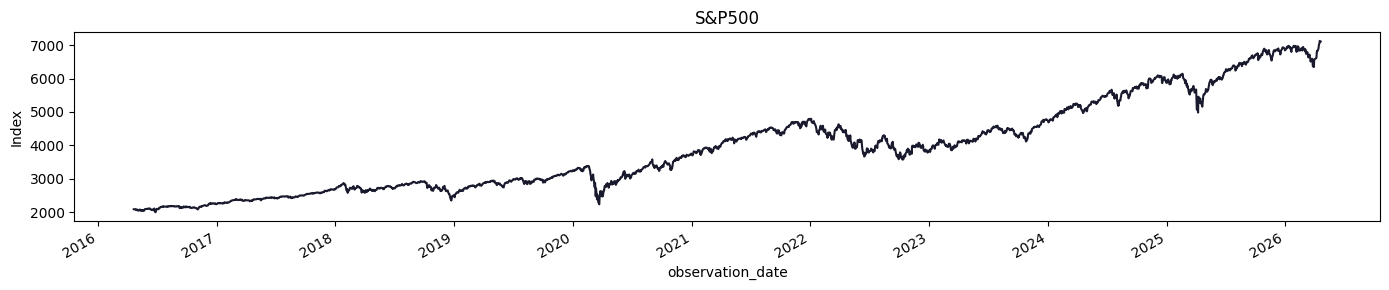

In [25]:
prices = load_prices(DATA_PATH)
print(f"Series: {len(prices)} bars  {prices.index[0].date()} to {prices.index[-1].date()}")

prices.plot(figsize=(14, 3), title="S&P500", color="#1a1a2e")
plt.ylabel("Index")
plt.tight_layout()

## 2. Run the miner — euclidean z-norm

`euclidean_znorm` is the default metric: fast, shape-based, scale-invariant. Good for daily equity data.

In [26]:
miner = AnalogMiner(window_size=60, forecast_horizon=20, metric="euclidean_znorm", top_k=3)
result = miner.find(prices)
summarize(result, "Euclidean z-norm  L=60 H=20")


=== Euclidean z-norm  L=60 H=20 ===
Query window: 2026-01-23 to 2026-04-20
Query realized vol: 0.0095 | Query cum return: +0.0279
Found 3 matches (top-K, min-separated):
  [0] 2016-04-25 -> 2016-07-19 | dist=8.1717 | vol=0.0086 | cum_ret=+0.0339 | fwd_ret=+0.0066
  [1] 2024-05-30 -> 2024-08-23 | dist=8.6580 | vol=0.0094 | cum_ret=+0.0675 | fwd_ret=+0.0148
  [2] 2018-05-02 -> 2018-07-26 | dist=8.7061 | vol=0.0058 | cum_ret=+0.0665 | fwd_ret=+0.0069
Forward dispersion across matches: 0.0081
Forward quantile bands (normalized to 1.0 at t=0):
       0.1     0.5     0.9
0   1.0000  1.0000  1.0000
10  0.9819  0.9958  1.0033
19  1.0046  1.0135  1.0172


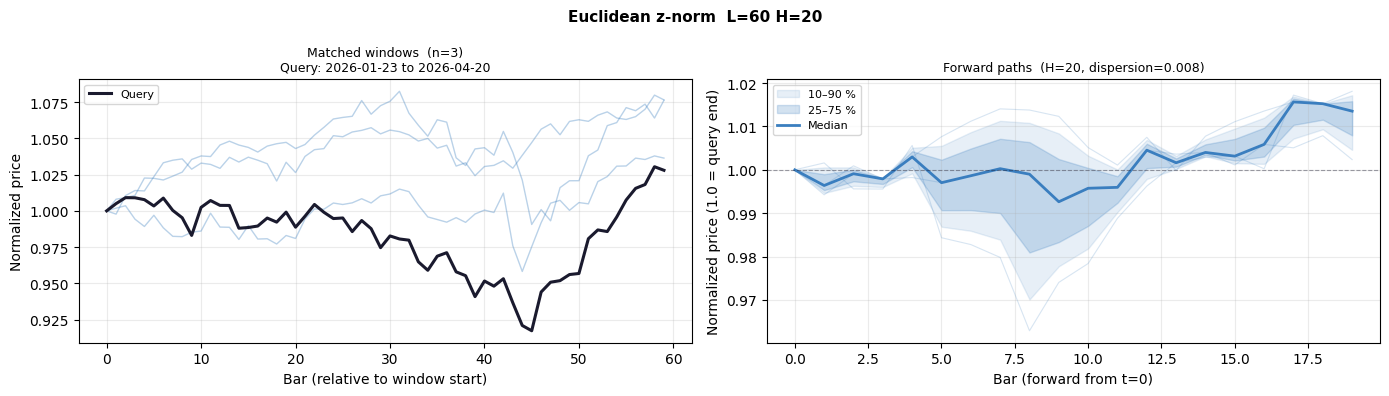

In [27]:
fig, _, _ = plot_result(result, "Euclidean z-norm  L=60 H=20")
plt.tight_layout()
plt.show()

## 3. Metrics comparison

| Metric | Shape of matching | Speed |
|---|---|---|
| `euclidean_znorm` | Euclidean on z-normalized returns | Fast — O(L) |
| `dtw` | Dynamic Time Warping with Sakoe-Chiba band; allows local time warping | Slower — O(L x band), pruned by LB_Keogh |

The fan charts below show how much each metric agrees or disagrees about the forward outlook.

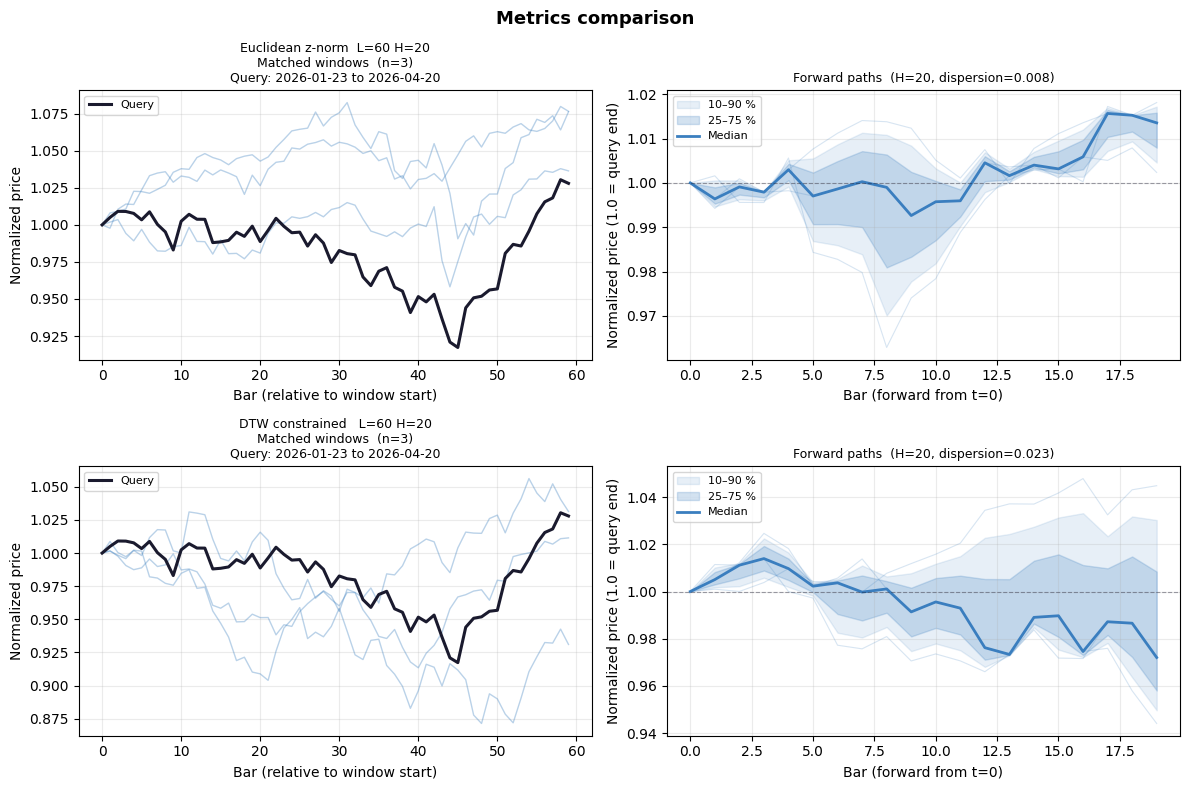

In [28]:
configs = [
    ("Euclidean z-norm  L=60 H=20", dict(window_size=60, forecast_horizon=20, metric="euclidean_znorm", top_k=3)),
    ("DTW constrained   L=60 H=20", dict(window_size=60, forecast_horizon=20, metric="dtw",             top_k=3, vol_band=(0.7, 1.5))),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Metrics comparison", fontsize=13, fontweight="bold")

for row, (label, cfg) in enumerate(configs):
    r = AnalogMiner(**cfg).find(prices)
    plot_result(r, label, ax_windows=axes[row, 0], ax_forward=axes[row, 1])
    axes[row, 0].set_title(f"{label}\n{axes[row, 0].get_title()}", fontsize=9)

plt.tight_layout()
plt.show()

## 4. Forward distribution table

The quantile bands summarize where the forward paths ended up at each bar. Wide spread = matches disagree about what comes next (high dispersion).

In [29]:
result.forward_distribution(quantiles=(0.1, 0.25, 0.5, 0.75, 0.9)).round(4)

,0.10,0.25,0.50,0.75,0.90
0,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9947,0.9953,0.9964,0.9990,1.0006
2,0.9963,0.9974,0.9991,1.0000,1.0006
3,0.9960,0.9967,0.9979,0.9980,0.9980
4,0.9992,1.0006,1.0030,1.0043,1.0051
5,0.9869,0.9907,0.9970,1.0023,1.0055
6,0.9859,0.9907,0.9986,1.0049,1.0087
7,0.9839,0.9900,1.0003,1.0072,1.0113
8,0.9701,0.9809,0.9990,1.0064,1.0108
9,0.9778,0.9833,0.9926,1.0025,1.0084


## 5. Query a specific historical date

You can anchor the query window at any date in the series by passing `query_end`. Here we look at what patterns resembled the 60 bars ending 2018-06-15, and what followed them.


=== Query ending 2018-06-15 ===
Query window: 2018-03-22 to 2018-06-15
Query realized vol: 0.0099 | Query cum return: +0.0247
Found 8 matches (top-K, min-separated):
  [0] 2023-03-10 -> 2023-06-05 | dist=4.9551 | vol=0.0088 | cum_ret=+0.0868 | fwd_ret=+0.0397
  [1] 2019-08-12 -> 2019-11-04 | dist=5.0288 | vol=0.0091 | cum_ret=+0.0532 | fwd_ret=+0.0048
  [2] 2016-09-09 -> 2016-12-02 | dist=5.1320 | vol=0.0071 | cum_ret=+0.0049 | fwd_ret=+0.0296
  [3] 2021-03-04 -> 2021-05-27 | dist=5.1538 | vol=0.0083 | cum_ret=+0.0951 | fwd_ret=+0.0188
  [4] 2018-12-21 -> 2019-03-20 | dist=5.1747 | vol=0.0112 | cum_ret=+0.1351 | fwd_ret=+0.0266
  [5] 2020-10-19 -> 2021-01-13 | dist=5.2542 | vol=0.0100 | cum_ret=+0.0895 | fwd_ret=+0.0276
  [6] 2022-06-01 -> 2022-08-25 | dist=5.4185 | vol=0.0145 | cum_ret=+0.0161 | fwd_ret=-0.1284
  [7] 2024-07-24 -> 2024-10-16 | dist=5.4345 | vol=0.0102 | cum_ret=+0.0503 | fwd_ret=+0.0242
Forward dispersion across matches: 0.0196
Forward quantile bands (normalized to 1

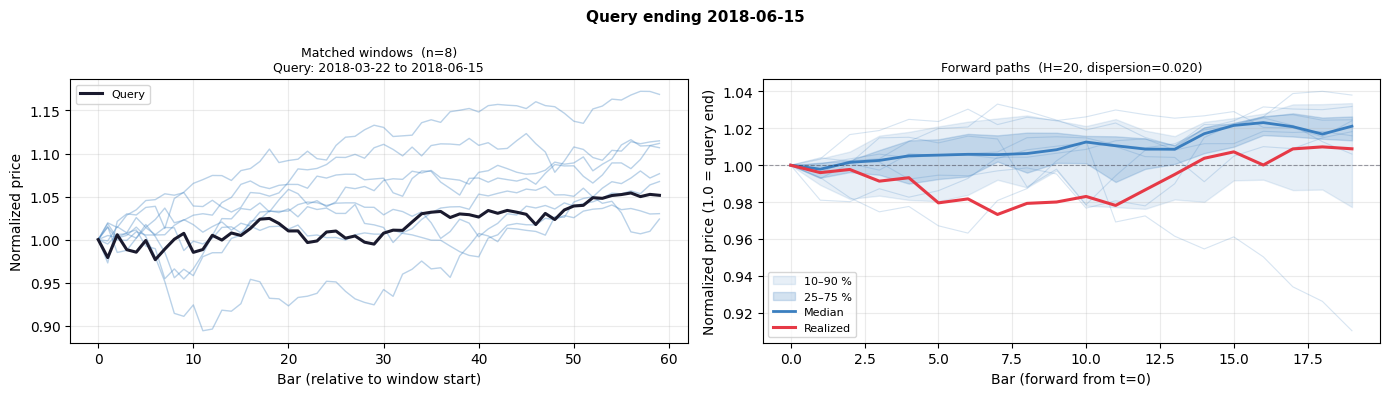

In [30]:
query_end = "2018-06-15"
miner_hist = AnalogMiner(window_size=60, forecast_horizon=20, metric="dtw", top_k=8, vol_band=(0.7, 1.5))
result_hist = miner_hist.find(prices, query_end=query_end)
summarize(result_hist, f"Query ending {query_end}")

# Extract the realized forward path from the actual price series
H = miner_hist.H
pos = prices.index.get_loc(result_hist.query_window.index[-1])
realized_prices = prices.iloc[pos + 1 : pos + 1 + H].values.astype(float)
realized_norm = realized_prices / realized_prices[0]

fig, _, _ = plot_result(result_hist, f"Query ending {query_end}", realized=realized_norm)
plt.tight_layout()
plt.show()